#Yinelemeli Sinir Ağları(RNN) Uygulaması
###Veri seti: IMBD film yorumları
#Hedefler:
###RNN temel prensiplerini ve yapısını anlamak

*   IMBD veri seti ile sınıflandırma problemini çözmekListe öğesi
*   Keras ile RNN modelini nasıl oluşturup eğitileceğini öğrenmek
*   Model performansını değerlendirme yöntemlerini kavramak
*   Hiperparametre optimizasyonunu uygulamak


#####Yararlanılan Kaynak: BTK Akademi Keras İle Derin Öğrenme Algoritmaları
#####Eğitmen : Kaan Can YILMAZ


In [23]:
pip install keras_tuner

In [24]:
# %% Veri setinin içeri aktarılmasıi padding
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.datasets import imdb #veri seti
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense,Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, auc, roc_curve

from keras_tuner import RandomSearch

import warnings
warnings.filterwarnings("ignore")

#veri seti yükle, imbd 50000,(0, olumsuz),(1, olumlu)
(x_train,y_train),(x_test,y_test)=imdb.load_data(num_words=10000) # num_words demek en sık kullanılan 10.000 kelimeyi al

In [25]:
#veri ön işleme : yorumlari ayni uzunluga getirmek icin padding yontemi kullandık.
maxlen=100
x_train=pad_sequences(x_train,maxlen=maxlen) #train verisi uzunlugu ayarla
x_test=pad_sequences(x_test,maxlen=maxlen) # test verisi uzunlugu ayarla

In [26]:
#%% create and compile RNN model

def build_model (hp): # hp : hyperparameter

  model=Sequential() #base model

  #embedding katmani: kelimeleri vektörlere cevirir.
  model.add(Embedding(input_dim=10000,
                      output_dim=hp.Int("embedding_output",min_value=32,max_value=128,step=32), # vektör boyutları (32 64 96 128)
                      input_length=maxlen))

  #RNN katmani
  model.add(SimpleRNN(units=hp.Int("rnn_units",min_value=32,max_value=128,step=32))) #rnn hücre sayisi  (32 64 96 128) olabilir

  #dropout katmani: overfittingi egellemek için rasgele bazi celleri kapatir
  model.add(Dropout(rate=hp.Float("dropout",min_value=0.2,max_value=0.5,step=0.1)))

  #çikti katmani : 1 cell ve sigmoid
  model.add(Dense(units=1,activation="sigmoid")) # sigmoid activation : ikili siniflandirma yapar(binary 0, 1)

  #modelin compile edilmesi
  model.compile(optimizer=hp.Choice("optimizer",["adam","rmsprop"]),
                loss="binary_crossentropy",
                metrics=["accuracy","AUC"])

  return model

Bir fonksiyon tanımladık. Bu fonksiyon hp diye parametre alıyor. Hiperparametreleri bulmak için RNN modelimizi inşa etmek için önce bir kelimeleri vektöre çeviren Embedding katmanı, ardından dizisel verileri öğrenmesi için bir Simple RNN katmanı ekledik. Modelin ezberlemesini (overfitting) önlemek amacıyla araya bir Dropout katmanı koyduk. Çıktı kısmında ise ikili sınıflandırma yapabilmek için sigmoid aktivasyonlu tek hücreli bir Dense katmanı kullandık. Son olarak, en iyi optimizer'ı seçmesi için "adam" ve "rmsprop" seçeneklerini sunarak modeli binary_crossentropy kaybı ve başarı metrikleriyle derledik (compile).


In [27]:
import keras_tuner

# %% hyperparameter search, model train

# hyperparameter search, randomsearch ile yapacağız. rasgele seçtircez belirli sayida gridsearch(tüm kombinasyonları dener)

tuner=keras_tuner.RandomSearch(
    build_model,#optimize edilecek model fonksiyonu
    objective="val_loss", # en düşük olan en iyisidire göre yapacak
    max_trials=5, # eğitim oldugu icin 2 tane denedik( normalde artirmak lazim)
    executions_per_trial=1,# her model için 1 egitim denemesi
    directory="rnn_tuner_directory",#modellerin kayit dilecegi dizin
    project_name="keras_ile_imdn_rnn"
    )

#erken durdurma: dogrula hatasi duzulmezse (azalmaz ise) egitimi durdur
early_stopping = EarlyStopping(monitor="val_loss",patience=3,restore_best_weights=True)

#modelin eğitimi
tuner.search(x_train,y_train,epochs=10,
             validation_split=0.2,
             callbacks=[early_stopping],
             )

Trial 5 Complete [00h 02m 08s]
val_loss: 0.40813934803009033

Best val_loss So Far: 0.395501971244812
Total elapsed time: 00h 34m 30s


In [28]:
# %% evaulate best model
# en iyi modelin alinamsi
best_model=tuner.get_best_models(num_models=1)[0]

#en iyi modeli kullanarak test et
loss, accuracy, auc_score=best_model.evaluate(x_test,y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test AUC: {auc_score:.4f}")

#tahmin yapma ve modelin performansnı degerlendirme
y_pred_prob=best_model.predict(x_test) #olasılık var %80 %70 gibi
y_pred=(y_pred_prob>0.5).astype("int32") # tahmin edilen degerler 0.5den buyuk olanlar icin 1 e yuvarlar ; kucuk olanlar icin 0 yapar.

782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - AUC: 0.9127 - accuracy: 0.8336 - loss: 0.3894
Test Loss: 0.3894
Test Accuracy: 0.8336
Test AUC: 0.9127
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step


In [29]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.80      0.89      0.84     12500
           1       0.88      0.78      0.82     12500

    accuracy                           0.83     25000
   macro avg       0.84      0.83      0.83     25000
weighted avg       0.84      0.83      0.83     25000



In [32]:
from sklearn.metrics import auc, roc_curve
#roc curve hesaplama
fpr,tpr,_=roc_curve(y_test,y_pred_prob)
roc_auc=auc(fpr,tpr)

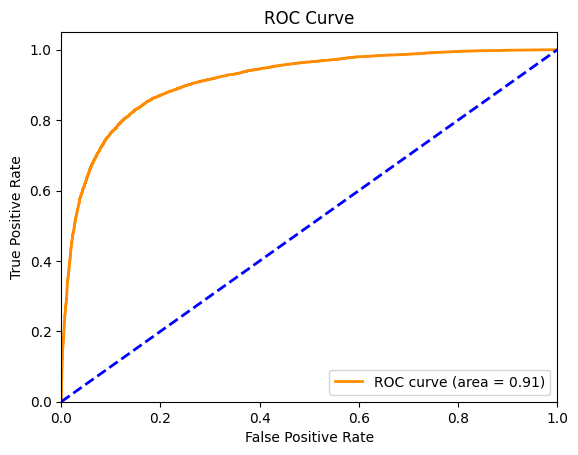

In [33]:
# roc curve gorsellestirme
plt.figure()
plt.plot(fpr,tpr,color="darkorange",lw=2,label="ROC curve (area = %0.2f)"%roc_auc)
plt.plot([0,1],[0,1],color="blue",lw=2,linestyle="--")
plt.xlim([0,1])
plt.ylim([0,1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
#


### ROC Eğrisi Yorumu

Yukarıdaki ROC eğrisi, modelimizin doğru sınıflandırma yeteneğini gösterir. Eğri sol üst köşeye ne kadar yakınsa, model o kadar iyidir.

**AUC (Eğri Altındaki Alan) değeri: %0.91**

Bu değer, modelimizin genel performansını özetler. %0.91'lik bir AUC, modelimizin pozitif ve negatif yorumları sınıflandırmada oldukça başarılı olduğunu ve tahminlerinin rastgele olmaktan çok daha iyi olduğunu gösterir.